# Stacked Bar Chart

Runnable example from the accompanying README. Run the code cell below to generate the chart.


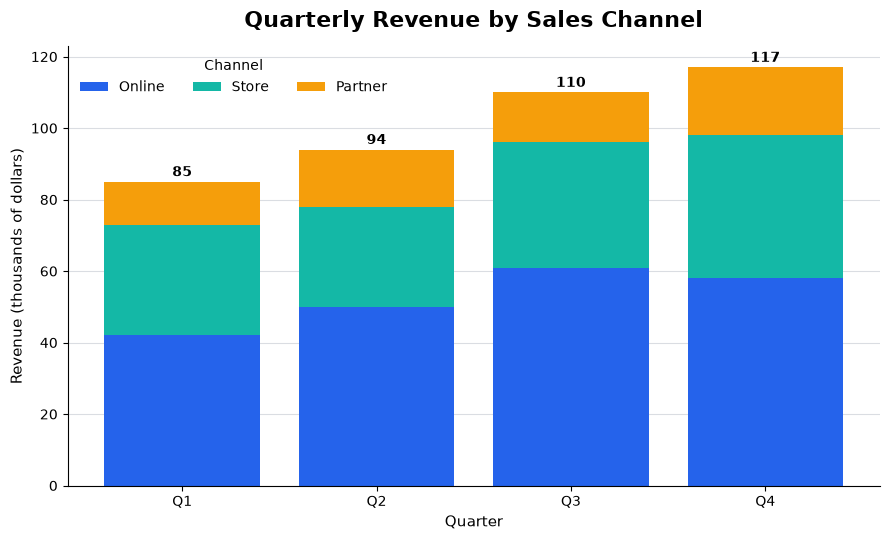

In [1]:
import matplotlib.pyplot as plt

# 1. Define the main categories and the values for each component.
quarters = ["Q1", "Q2", "Q3", "Q4"]
online_sales = [42, 50, 61, 58]
store_sales = [31, 28, 35, 40]
partner_sales = [12, 16, 14, 19]

# 2. Create a figure and axes for the chart.
fig, ax = plt.subplots(figsize=(9, 5.5))

# 3. Draw the bottom layer first. This layer starts at zero.
online_bars = ax.bar(
    quarters,
    online_sales,
    label="Online",
    color="#2563EB",
)

# 4. Stack the next layer on top by setting `bottom` to the layer beneath it.
store_bars = ax.bar(
    quarters,
    store_sales,
    bottom=online_sales,
    label="Store",
    color="#14B8A6",
)

# 5. Calculate the cumulative height for the final layer.
#    Each Partner segment begins above the combined Online and Store values.
online_and_store = [online + store for online, store in zip(online_sales, store_sales)]
partner_bars = ax.bar(
    quarters,
    partner_sales,
    bottom=online_and_store,
    label="Partner",
    color="#F59E0B",
)

# 6. Add a title, labels, and a legend explaining the color mapping.
ax.set_title(
    "Quarterly Revenue by Sales Channel", fontsize=16, fontweight="bold", pad=14
)
ax.set_xlabel("Quarter", fontsize=11)
ax.set_ylabel("Revenue (thousands of dollars)", fontsize=11)
ax.legend(title="Channel", frameon=False, ncols=3, loc="upper left")

# 7. Use a zero baseline and a light horizontal grid for reliable comparisons.
ax.set_ylim(bottom=0)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)

# 8. Label the total at the top of every stack.
totals = [
    online + store + partner
    for online, store, partner in zip(online_sales, store_sales, partner_sales)
]
for quarter, total in zip(quarters, totals):
    ax.annotate(
        f"{total}",
        xy=(quarter, total),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# 9. Remove unnecessary borders, adjust spacing, save, and display the chart.
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("stacked_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()